# Breast Cancer Diagnosis Using Machine Learning

## Capstone Project

This project aims to diagnose breast cancer (benign or malignant) using cytology features from biopsy samples.

Dataset:
Breast Cancer Wisconsin Dataset

Goal:
Build machine learning models to classify tumors as:
- Benign (2)
- Malignant (4)

In the Breast Cancer Wisconsin dataset,
the class labels are encoded as numbers,
where 2 represents benign tumors
and 4 represents malignant tumors.

Technologies used:
- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-Learn

# Phase 1: Data Analysis and Preparation

In this phase we:
- Load the dataset
- Inspect the data
- Clean the dataset
- Prepare features and labels

### Import Required Libraries

In this section, the necessary Python libraries for data analysis, visualization, and machine learning are imported.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Load the Dataset

The dataset is loaded from a CSV file.
The head() function is used to display
the first five rows of the dataset
to check the structure and column names.

In [2]:
data = pd.read_csv("breastCancer.csv")

data.head()

,id,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


### Inspect the Dataset

In this step, we examine the structure of the dataset to understand the data types, number of features, and whether there are missing values.


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 699 non-null    int64 
 1   clump_thickness    699 non-null    int64 
 2   size_uniformity    699 non-null    int64 
 3   shape_uniformity   699 non-null    int64 
 4   marginal_adhesion  699 non-null    int64 
 5   epithelial_size    699 non-null    int64 
 6   bare_nucleoli      699 non-null    object
 7   bland_chromatin    699 non-null    int64 
 8   normal_nucleoli    699 non-null    int64 
 9   mitoses            699 non-null    int64 
 10  class              699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


### Statistical Summary of the Data

The `describe()` function provides statistical information such as mean, standard deviation, minimum, and maximum values for the numerical features in the dataset.


In [4]:
data.describe()

,id,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bland_chromatin,normal_nucleoli,mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


### Feature Correlation Heatmap

The correlation heatmap shows the relationships between numerical features in the dataset. This helps identify how strongly features are related to each other.

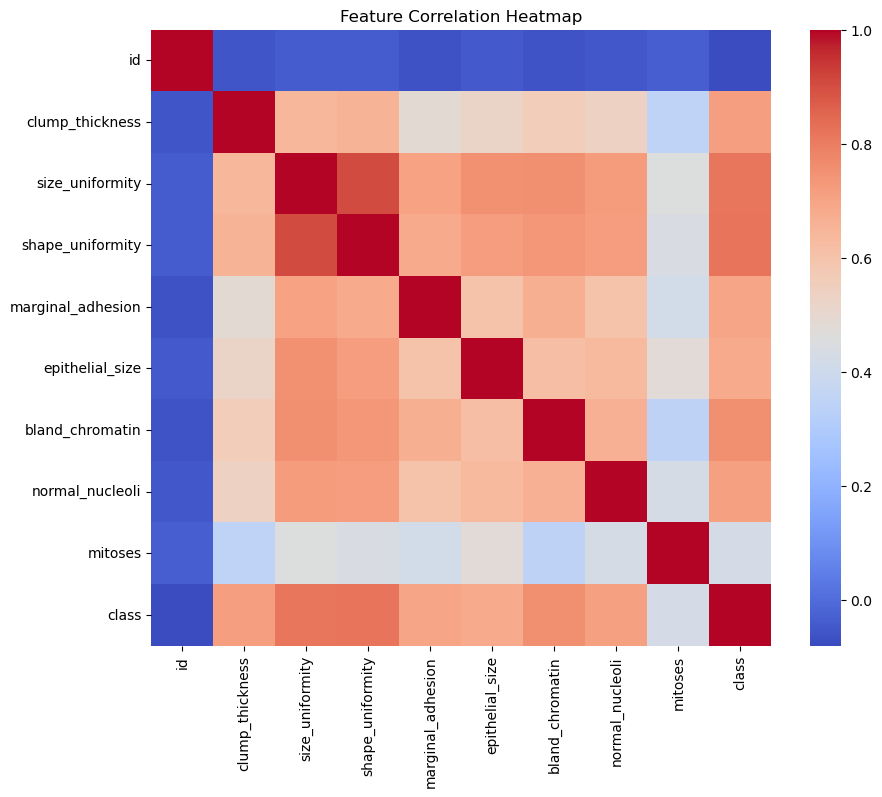

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

### Interpretation of the Correlation Heatmap

Several features such as size_uniformity, shape_uniformity, bland_chromatin, and normal_nucleoli show strong positive correlation with the target variable (class), indicating that they are important for distinguishing between benign and malignant tumors.

The id column has very low correlation with other features, confirming that it is not useful for prediction and should be removed.

Some features are also highly correlated with each other, which is expected in medical datasets where multiple measurements describe similar properties.





### Data Cleaning

In this step, the unnecessary column (Sample code number) is removed,
missing values are handled, and the dataset is cleaned
before applying machine learning models.

In [6]:
data = data.drop(columns=['id'])

data = data.replace("?", np.nan)

data = data.dropna()

data.head()

,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


### Data Preprocessing – Convert to numeric and remove missing values

The "bare_nucleoli" column is converted to numeric format,
and remaining missing values are removed
to prepare the dataset for machine learning.

In [7]:
data["bare_nucleoli"] = pd.to_numeric(data["bare_nucleoli"], errors="coerce")
data = data.dropna()
data.head()

,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


### Define features and target

Input features are stored in X,
and the target variable (class) is stored in y.

In [8]:
X = data.drop("class", axis=1)
y = data["class"]

### Split data into training and testing sets

Train-test split is used to prevent overfitting
and evaluate model performance.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

StandardScaler is applied to normalize the features,
because models such as KNN, Logistic Regression,
and Neural Network are sensitive to feature magnitude.

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Phase 2: Model Selection

This is a classification problem, so the following machine learning models are selected for comparison:
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Neural Network

### Import machine learning models

Logistic Regression, KNN, Decision Tree,
and Neural Network models are imported
for model training and comparison.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Phase 3: Model Design


### Model initialization

In this step, the selected machine learning models are initialized with predefined parameters.
This is required before training, because the model must be created before it can learn from the data.

In [12]:
log_model = LogisticRegression()
knn_model = KNeighborsClassifier(n_neighbors=5)
tree_model = DecisionTreeClassifier()
nn_model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)

# Phase 4: Model Training

All initialized machine learning models are trained
using the training dataset so they can learn
the relationship between features and target values.

### Train models

All models are trained using the training data.

In [13]:
log_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)

# Model Evaluation

The trained models are evaluated using the test data.
Each model makes predictions,
and accuracy is calculated to compare performance.

### Import accuracy metric

Accuracy score is used to measure model performance.

In [14]:
from sklearn.metrics import accuracy_score

### Generate predictions

Each trained model makes predictions
on the test dataset.

In [15]:
log_pred = log_model.predict(X_test)
knn_pred = knn_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
nn_pred = nn_model.predict(X_test)

### Calculate model accuracy

Accuracy score is computed for each model
to determine which model performs best.

In [16]:
log_acc = accuracy_score(y_test, log_pred)
knn_acc = accuracy_score(y_test, knn_pred)
tree_acc = accuracy_score(y_test, tree_pred)
nn_acc = accuracy_score(y_test, nn_pred)

print("Logistic Regression Accuracy:", log_acc)
print("KNN Accuracy:", knn_acc)
print("Decision Tree Accuracy:", tree_acc)
print("Neural Network Accuracy:", nn_acc)

Logistic Regression Accuracy: 0.9562043795620438
KNN Accuracy: 0.9635036496350365
Decision Tree Accuracy: 0.9416058394160584
Neural Network Accuracy: 0.9781021897810219


### Confusion Matrix – Final Model

The confusion matrix is used to evaluate the performance
of the Neural Network model, which was selected as the final model
because it achieved the highest accuracy.

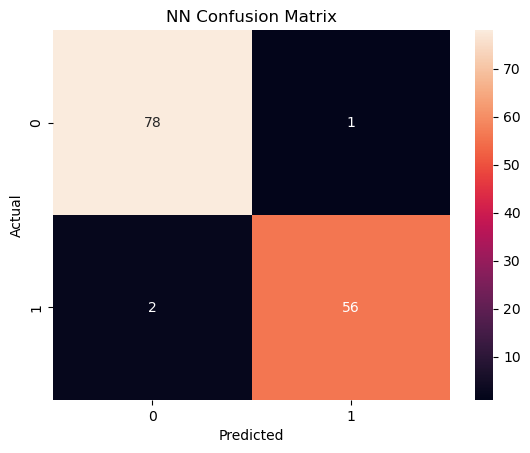

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, nn_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("NN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation of the Confusion Matrix

- **78** – The model correctly classified **78 benign tumors** (True Negatives).
- **1** – The model incorrectly classified **1 benign tumor as malignant** (False Positive).
- **3** – The model incorrectly classified **4 malignant tumors as benign** (False Negative).
- **55** – The model correctly classified **54 malignant tumors** (True Positives).

The model correctly classified 78 benign tumors and 55 malignant tumors, while only 4 cases were misclassified.

### Classification Report – Final Model

The classification report is used to evaluate the performance
of the Neural Network model, which achieved the highest accuracy.
It includes precision, recall, F1-score, and support.

In [18]:
from sklearn.metrics import classification_report

print("Classification Report for NN Model:\n")
print(classification_report(y_test, nn_pred))


Classification Report for NN Model:

              precision    recall  f1-score   support

           2       0.97      0.99      0.98        79
           4       0.98      0.97      0.97        58

    accuracy                           0.98       137
   macro avg       0.98      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137



The first column shows the class labels,
where 2 is benign and 4 is malignant.

Precision shows how many predicted cases were correct,
recall shows how many real cases were detected,
and F1-score is the balance between them.
Support shows the number of samples in each class.

Since all values are close to 1,
the neural network model performs very well.

### ROC Curve – Final Model

The ROC curve evaluates the performance of the Neural Network model,
which was selected as the final model.
It shows how well the model separates the two classes.
A higher AUC value indicates better performance.

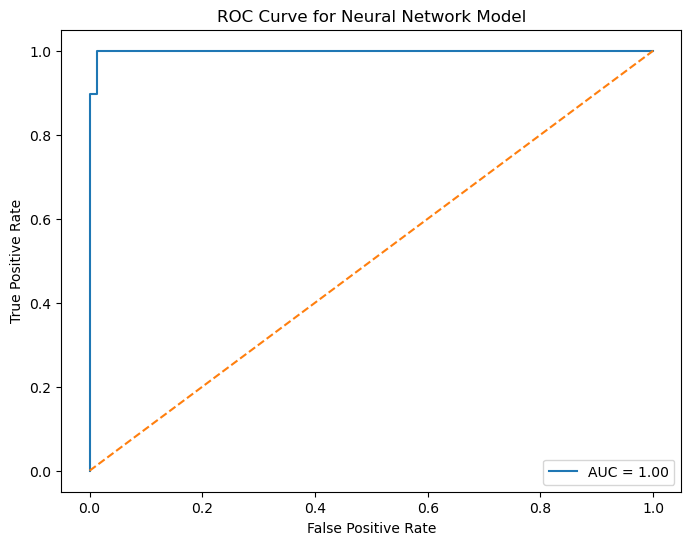

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Convert class labels from 2/4 to 0/1
y_test_binary = y_test.replace({2: 0, 4: 1})

# Get prediction probabilities from Neural Network model
nn_prob = nn_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test_binary, nn_prob)
auc_score = roc_auc_score(y_test_binary, nn_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Neural Network Model")
plt.legend()
plt.show()

### Interpretation of ROC Curve
The ROC curve evaluates the ability of the neural network
to distinguish between benign and malignant tumors.

The AUC value of 1.00 indicates excellent performance,
meaning the model can separate the two classes very well.

This also suggests that the dataset is relatively easy to classify.

# Phase 5: Final Performance Results
In this phase, the performance of all trained models
is compared using their accuracy scores on the test dataset.

A bar chart is used to visually compare the models
and determine which algorithm achieves the best classification performance.

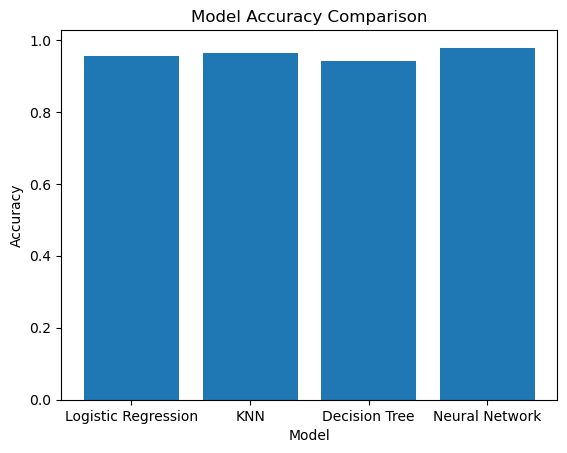

In [20]:
models = ["Logistic Regression", "KNN", "Decision Tree", "Neural Network"]
accuracies = [log_acc, knn_acc, tree_acc, nn_acc]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

# Conclusion

In this project, multiple machine learning models were implemented
to classify breast cancer tumors as benign or malignant
using the Breast Cancer dataset.

The tested models included Logistic Regression, KNN,
Decision Tree, and Neural Network.

After evaluation, the Neural Network showed the highest accuracy,
while the other models also achieved strong performance.

The results show that machine learning techniques
can be very useful in medical diagnosis,
helping doctors make faster and more reliable decisions.

In future work, more advanced algorithms and cross-validation
can be used to further improve model performance.